In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import statistics as st

import functools as ft

import scipy as sc
from scipy.stats import norm
from scipy.signal import welch
from scipy.stats import linregress

import cartopy.crs as ccrs

from eofs.xarray import Eof



In [56]:
path_name = './data/mslp.mon.mean.nc' 
ds = xr.open_dataset(path_name, decode_timedelta=True)

mslp = ds.mslp

# standardise

mslp = mslp.groupby("time.month") - mslp.groupby("time.month").mean("time")
#mslp = mslp / mslp.std(dim="time")

darwin = mslp.sel(lat=slice(-10,-15)).sel(lon=slice(127.5,132.5)).mean(dim=("lat", "lon"))
tahiti = mslp.sel(lat=slice(-12.5,-17.5)).sel(lon=slice(212.5,217.5)).mean(dim=("lat", "lon"))

elnino = xr.concat([darwin, tahiti], dim="space")
elnino = elnino.transpose("time", "space")

elnino["space"] = ["Darwin", "Tahiti"]




In [57]:

solver = Eof(elnino)

eofs = solver.eofs(neofs=2)
pcs = solver.pcs(npcs=2, pcscaling=1)
variance = solver.varianceFraction()

In [58]:
print(eofs)

<xarray.DataArray 'eofs' (mode: 2, space: 2)> Size: 16B
array([[-0.744886  ,  0.66719174],
       [-0.66719174, -0.744886  ]], dtype=float32)
Coordinates:
  * mode     (mode) int64 16B 0 1
  * space    (space) <U6 48B 'Darwin' 'Tahiti'
Attributes:
    long_name:  empirical_orthogonal_functions


0.00016148388223505468
-0.3872326923571332


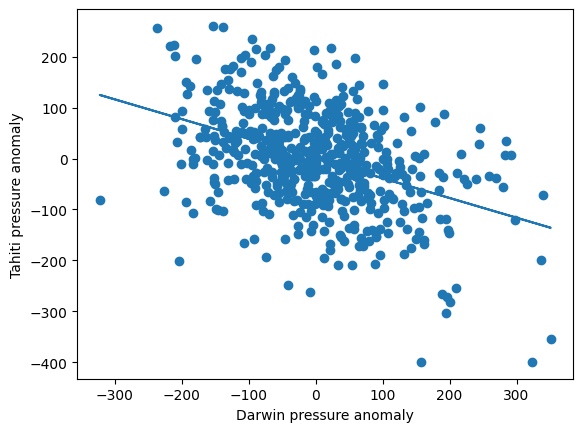

In [59]:
plt.scatter(darwin, tahiti)

b, a = np.polyfit(darwin, tahiti, 1)
plt.plot(darwin, a + b*darwin)
plt.xlabel("Darwin pressure anomaly")
plt.ylabel("Tahiti pressure anomaly")
plt.savefig('darwin-tahiti-scatter.pdf')

print(a)
print(b)

In [60]:
np.correlate(darwin, tahiti)

array([-2.330182e+06], dtype=float32)

In [61]:
print(np.corrcoef(darwin,tahiti))

[[ 1.        -0.4049264]
 [-0.4049264  1.       ]]


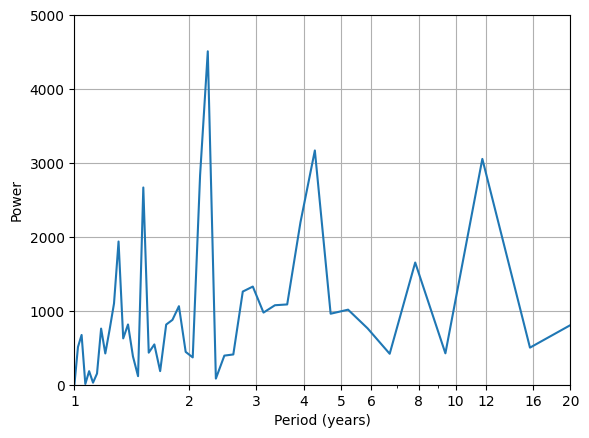

In [62]:
pc1 = pcs[:,1]
# remove mean
x = pc1.values - pc1.values.mean()

N = len(x)
dt = 1/12  # years

fft_vals = np.fft.fft(x)
freqs = np.fft.fftfreq(N, d=dt)


power = np.abs(fft_vals)**2

mask = freqs > 0
freqs = freqs[mask]
power = power[mask]

period_years = 1 / freqs

plt.plot(period_years, power)
plt.xlim(1,20)
plt.ylim(0,5000)
plt.xlabel("Period (years)")
plt.ylabel("Power")
plt.xscale("log")  # optional but very useful
plt.grid()
plt.xticks(ticks=[1, 2, 3, 4, 5, 6,8,10, 12, 16, 20], labels=[1, 2, 3, 4,5,6,8,10,12, 16, 20])

plt.savefig('darwin-tahiti-pc1.pdf')
plt.show()


In [63]:
result = linregress(darwin, tahiti)

print(result.slope)
print(result.intercept)
print(result.rvalue)   # correlation
print(result.pvalue)

-0.387232692357133
0.00016236206235839163
-0.40492639894116145
1.1499458468723793e-23


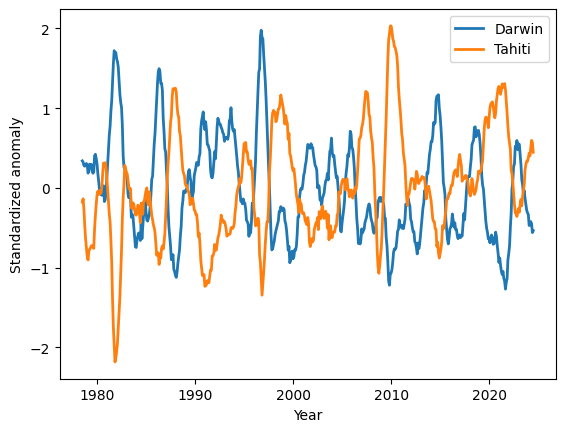

In [64]:


darwin_std = (darwin - darwin.mean(dim="time")) / darwin.std(dim="time")
tahiti_std = (tahiti - tahiti.mean(dim="time")) / tahiti.std(dim="time")

darwin_12m = darwin_std.rolling(time=12, center=True).mean()
tahiti_12m = tahiti_std.rolling(time=12, center=True).mean()

time_years = (np.arange(darwin_std.sizes["time"]) / 12) + 1978


plt.plot(time_years, darwin_12m, linewidth=2, label="Darwin")
plt.plot(time_years, tahiti_12m, linewidth=2, label="Tahiti")

plt.xlabel("Year")
plt.ylabel("Standardized anomaly")
plt.legend()

plt.savefig('darwin-tahiti-running.pdf')
plt.show()

In [65]:
darwin_corr = xr.corr(mslp, darwin, dim="time")
tahiti_corr = xr.corr(mslp, tahiti, dim="time")

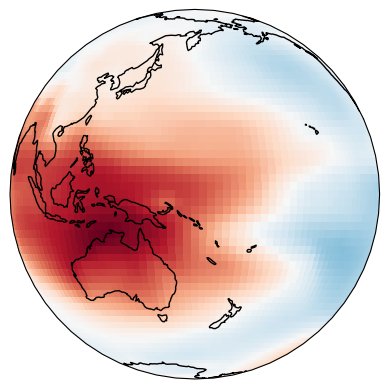

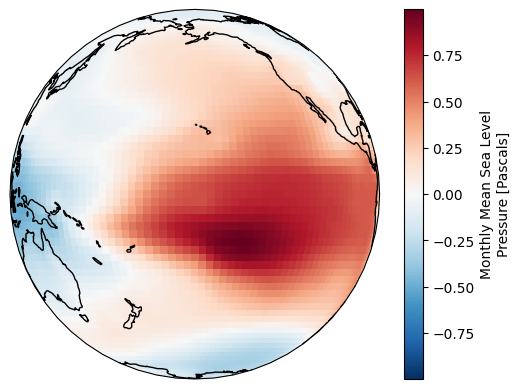

In [66]:
p = darwin_corr.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(160, 0), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
p.axes.set_global()

p.axes.coastlines();

plt.savefig('darwin-pacific.pdf')
plt.show()

p = tahiti_corr.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-160, 0), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    
)
p.axes.set_global()

p.axes.coastlines();

plt.savefig('tahiti-pacific.pdf')

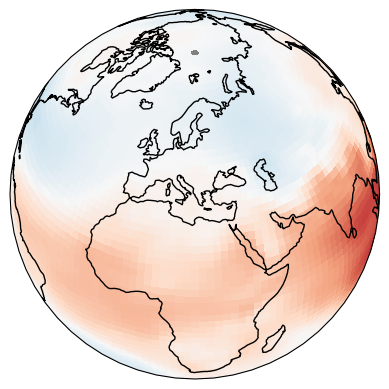

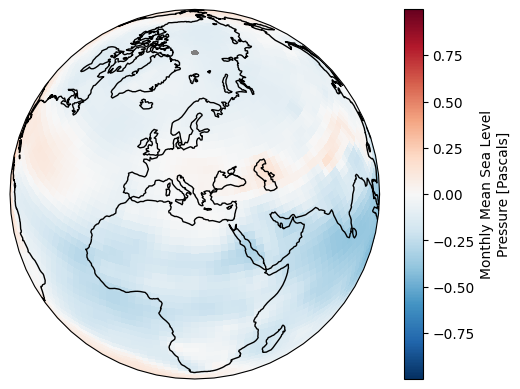

In [67]:
p = darwin_corr.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(20, 40), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
p.axes.set_global()

p.axes.coastlines();

plt.savefig('darwin-europe.pdf')
plt.show()

p = tahiti_corr.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(20, 40), facecolor="gray"),
    transform=ccrs.PlateCarree(),
    
)
p.axes.set_global()

p.axes.coastlines();

plt.savefig('tahiti-europe.pdf')

In [97]:
def linr(x, y):
    return linregress(x, y).slope

predictand = xr.apply_ufunc(
    linr,
    darwin,
    mslp,
    input_core_dims=[["time"], ["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
)

predictor = xr.apply_ufunc(
    linr,
    mslp,
    darwin,
    input_core_dims=[["time"], ["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
)

def pval(x, y):
    return linregress(x, y).pvalue

predictand_pvalues = xr.apply_ufunc(
    pval,
    darwin,
    mslp,
    input_core_dims=[["time"], ["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
)

predictor_pvalues = xr.apply_ufunc(
    pval,
    mslp,
    darwin,
    input_core_dims=[["time"], ["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
)


predictor_sig = predictor.where(predictor_pvalues < 0.01)

predictand_sig = predictand.where(predictand_pvalues < 0.01)

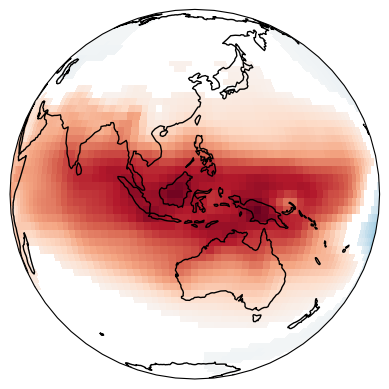

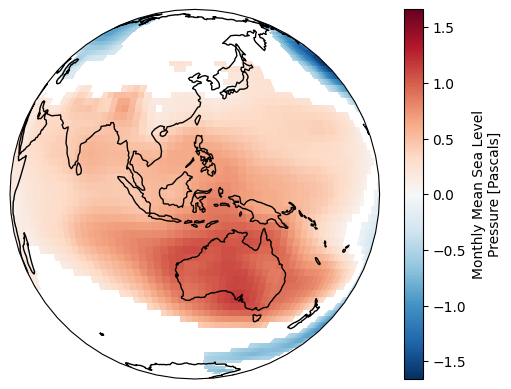

In [100]:
p = predictor_sig.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(120, 0), facecolor="white"),
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
p.axes.set_global()

p.axes.coastlines()


plt.savefig('darwin-predictor-india.pdf')
plt.show()


p = predictand_sig.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(120, 0), facecolor="white"),
    transform=ccrs.PlateCarree(),
    add_colorbar=True
)
p.axes.set_global()

p.axes.coastlines()


plt.savefig('darwin-predictand-india.pdf')


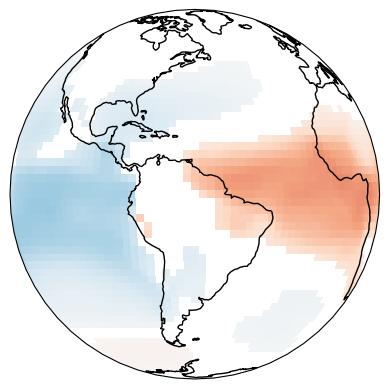

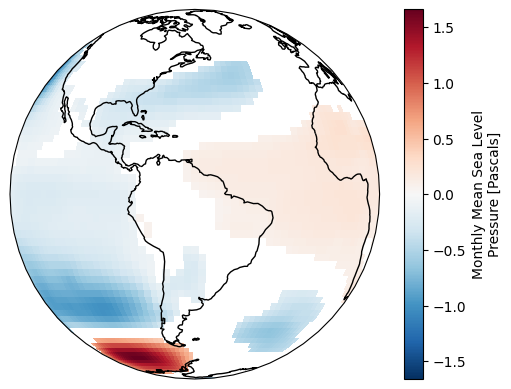

In [99]:


p = predictor_sig.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-60, 0), facecolor="white"),
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
p.axes.set_global()

p.axes.coastlines()


plt.savefig('darwin-predictor-atlantic.pdf')
plt.show()


p = predictand_sig.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-60, 0), facecolor="white"),
    transform=ccrs.PlateCarree(),
    add_colorbar=True
)
p.axes.set_global()

p.axes.coastlines()

plt.savefig('darwin-predictand-atlantic.pdf')


In [71]:
def pval(x, y):
    return linregress(x, y).pvalue

predictand_pvalues = xr.apply_ufunc(
    pval,
    darwin,
    mslp,
    input_core_dims=[["time"], ["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
)

In [101]:
predictand_sig

<xarray.DataArray 'mslp' (lat: 73, lon: 144)> Size: 84kB
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [-0.72186254, -0.72135867, -0.71951947, ..., -0.71676839,
        -0.71949518, -0.72116165],
       [-0.7555458 , -0.74935266, -0.74172619, ..., -0.76616936,
        -0.76412077, -0.76043191],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(73, 144))
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes: (12/14)
    long_name:      Monthly Mean Sea Level Pressure
    units:          Pascals
    precision:      0
    GRIB_id:        2
    GRIB_name:      PRMSL
    var_desc:       Mean Sea Level Pressure
    ...             ...
    statistic:      Individual Obs
    parent_stat:    Other
    standard_name:  pressure
    cell_methods:   time: mean (monthly from 6-hourly values)
    valid_range:    [ 77000. 125000.]
    actual_range:   [ 95644. 105703.]